In [109]:
from pyscf import gto, scf, cc

a = 2 # bond length in a cluster
d = 100 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 2 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'H'
basis = 'sto6g'
# for nc in nc_list:
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"

mol = gto.M(atom=atoms, basis="sto6g", unit='B', spin=0, verbose=4)
mol.build()

mf = scf.RHF(mol)
mf.kernel()

mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)
mo = mf.stability()[0]
dm = mf.make_rdm1(mo,mf.mo_occ)
mf.kernel(dm0=dm)

nfrozen = 0
mycc = cc.CCSD(mf,frozen=nfrozen)
mycc.kernel()[0]

System: uname_result(system='Linux', node='sharmagroup-rn', release='6.17.0-14-generic', version='#14~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Jan 15 15:52:10 UTC 2', machine='x86_64')  Threads 16
Python 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
numpy 2.3.1  scipy 1.16.2  h5py 3.14.0
Date: Wed Feb 25 19:28:07 2026
PySCF version 2.12.1
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD (branch master) f0861da51f017364d8bbaa20b742a94f3733305f

[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 4
[INPUT] num. electrons = 4
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 H      0.000000000000   0.000000000000   0.000000000000 AA    

np.float64(-0.07928280181561755)

In [110]:
# example for PT2

options = {'n_eql': 3,
           'n_prop_steps': 50,
            'n_ene_blocks': 1,
            'n_sr_blocks': 5,
            'n_blocks': 50,
            'n_walkers': 200,
            'seed': 2,
            'walker_type': 'rhf',
            'trial': 'stoccsd4',
            'nslater': 1,
            'dt':0.005,
            'free_projection':False,
            'fp_abs': False,
            'group': False,
            'ad_mode': None,
            'use_gpu': False,
            }

from ad_afqmc.prop_unrestricted.mixed_wave import prep
import jax
jax.config.update("jax_enable_x64", True)
prep.prep_afqmc(mycc,chol_cut=1e-5)
# prop_unrestricted.run_afqmc(options,nproc=1)
option_file='options.bin'
import pickle
with open(option_file, 'wb') as f:
    pickle.dump(options, f)

#
# Preparing AFQMC calculation
# Calculating Cholesky integrals
# Finished calculating Cholesky integrals
#
# Size of the correlation space:
# Number of electrons: (2, 2)
# Number of basis functions: 4
# Number of Cholesky vectors: 6
#


In [111]:
import time
import numpy as np
from jax import random
from jax import numpy as jnp
from functools import partial 

ham_data, ham, prop, trial, wave_data, sampler, options = (prep._prep_afqmc())

init_time = time.time()

### initialize propagation
init_walkers = None
trial_rdm1 = trial.get_rdm1(wave_data)
if "rdm1" not in wave_data:
    wave_data["rdm1"] = trial_rdm1
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)

prop_data = prop.init_prop_data(trial, wave_data, ham_data, init_walkers)
if jnp.abs(jnp.sum(prop_data["overlaps"])) < 1.0e-6:
    raise ValueError(
        "Initial overlaps are zero. Pass walkers with non-zero overlap."
    )
prop_data["key"] = random.PRNGKey(options["seed"])

wave_data['tau'], _ = trial.decompose_t2(wave_data)

prop_data["overlaps"] = trial.calc_overlap(prop_data["walkers"], wave_data)
prop_data["n_killed_walkers"] = 0

e_init= jnp.real(trial.calc_energy(prop_data["walkers"], ham_data, wave_data)[0])
# ept_sp = h0 + e0/t1 + e1/t1 - t2 * e0 / t1**2
# ept = jnp.array(jnp.sum(ept_sp) / prop.n_walkers)
prop_data["e_estimate"] = e_init
prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

print(e_init)
print(e_init-mf.e_tot)

# norb: 4
# nelec: (2, 2)
# n_eql: 3
# n_prop_steps: 50
# n_ene_blocks: 1
# n_sr_blocks: 5
# n_blocks: 50
# n_walkers: 200
# seed: 2
# walker_type: rhf
# trial: stoccsd4
# nslater: 1
# dt: 0.005
# free_projection: False
# fp_abs: False
# group: False
# use_gpu: False
# n_exp_terms: 6
# n_batch: 1
# max_error: 0.001
# Throw 2 vectors in T2 deomposition
# cutoff = 1.00e-06 | error = 1.40e-16
# number of T2 decomposition vectors 2
-2.1128597642000013
2.6645352591003757e-15


In [112]:
from jax import jit, lax

# class sampler_stoccsd2(sampler):
#     n_prop_steps: int = 50
#     n_ene_blocks: int = 1
#     n_sr_blocks: int = 5
#     n_blocks: int = 50
#     n_chol: int = 0

@partial(jit, static_argnums=(0,3,4))
def _block_eql(
    self,
    prop_data: dict,
    ham_data: dict,
    prop,
    trial,
    wave_data: dict
    ):
    """Block scan function. Propagation and energy calculation."""

    prop_data["key"], subkey = random.split(prop_data["key"])
    fields = random.normal(
        subkey,
        shape=(
            self.n_prop_steps,
            prop.n_walkers,
            self.n_chol,
        ),
    )
    _step_scan_wrapper = lambda x, y: self._step_scan(
        x, y, ham_data, prop, trial, wave_data
    )
    prop_data, _ = lax.scan(_step_scan_wrapper, prop_data, fields)
    prop_data["n_killed_walkers"] += prop_data["weights"].size - jnp.count_nonzero(
        prop_data["weights"]
    )

    # fields_x for T2 decomposition
    prop_data["key"], subkey = random.split(prop_data["key"])
    fields_x = random.normal(
        subkey,
        shape=(
            prop.n_walkers,
            trial.nslater,
            wave_data['tau'].shape[0],
        ),
    )

    xtaus = jnp.einsum("wsg,gia->wsia", fields_x, wave_data['tau'])

    prop_data = prop.orthonormalize_walkers(prop_data)
    overlap_hf = trial.calc_overlap(prop_data["walkers"], wave_data)
    prop_data["overlaps"] = overlap_hf
    overlap_ci, energy_ci = trial.calc_energy_ci(prop_data["walkers"], ham_data, wave_data)
    numerator_cr = trial.calc_numerator(prop_data["walkers"], xtaus, ham_data, wave_data)
    denominator_cr = trial.calc_denominator(prop_data["walkers"], xtaus, wave_data)


    num_ci = overlap_ci * energy_ci / overlap_hf
    den_ci = overlap_ci / overlap_hf
    num_cr = numerator_cr / overlap_hf
    den_cr = denominator_cr / overlap_hf


    whf = prop_data["weights"]

    blk_whf = jnp.sum(whf)
    blk_num_ci = jnp.sum(whf * num_ci) / blk_whf
    blk_den_ci = jnp.sum(whf * den_ci) / blk_whf
    blk_num_cr = jnp.sum(whf * num_cr) / blk_whf
    blk_den_cr = jnp.sum(whf * den_cr) / blk_whf

    return prop_data, (blk_whf, blk_num_ci, blk_den_ci, blk_num_cr, blk_den_cr)


@partial(jit, static_argnums=(0,3,4))
def _block_scan_cc(
    self,
    prop_data: dict,
    ham_data: dict,
    prop,
    trial,
    wave_data: dict
    ):
    """Block scan function. Propagation and energy calculation."""

    # prop_data["key"], subkey = random.split(prop_data["key"])
    # fields = random.normal(
    #     subkey,
    #     shape=(
    #         self.n_prop_steps,
    #         prop.n_walkers,
    #         self.n_chol,
    #     ),
    # )
    # _step_scan_wrapper = lambda x, y: self._step_scan(
    #     x, y, ham_data, prop, trial, wave_data
    # )
    # prop_data, _ = lax.scan(_step_scan_wrapper, prop_data, fields)
    # prop_data["n_killed_walkers"] += prop_data["weights"].size - jnp.count_nonzero(
    #     prop_data["weights"]
    # )

    # fields_x for T2 decomposition
    prop_data["key"], subkey = random.split(prop_data["key"])
    fields_x = random.normal(
        subkey,
        shape=(
            prop.n_walkers,
            trial.nslater,
            wave_data['tau'].shape[0],
        ),
    )

    xtaus = jnp.einsum("wsg,gia->wsia", fields_x, wave_data['tau'])

    prop_data = prop.orthonormalize_walkers(prop_data)
    overlap_hf = trial.calc_overlap(prop_data["walkers"], wave_data)
    prop_data["overlaps"] = overlap_hf
    overlap_ci, energy_ci = trial.calc_energy_ci(prop_data["walkers"], ham_data, wave_data)
    numerator_cr = trial.calc_numerator(prop_data["walkers"], xtaus, ham_data, wave_data)
    denominator_cr = trial.calc_denominator(prop_data["walkers"], xtaus, wave_data)


    num_ci = overlap_ci * energy_ci / overlap_hf
    den_ci = overlap_ci / overlap_hf
    num_cr = numerator_cr / overlap_hf
    den_cr = denominator_cr / overlap_hf


    whf = prop_data["weights"]

    blk_whf = jnp.sum(whf)
    blk_num_ci = jnp.sum(whf * num_ci) / blk_whf
    blk_den_ci = jnp.sum(whf * den_ci) / blk_whf
    blk_num_cr = jnp.sum(whf * num_cr) / blk_whf
    blk_den_cr = jnp.sum(whf * den_cr) / blk_whf

    return prop_data, (blk_whf, blk_num_ci, blk_den_ci, blk_num_cr, blk_den_cr)

In [113]:
neql = 10
block_time = prop.dt * sampler.n_prop_steps * sampler.n_ene_blocks * sampler.n_sr_blocks

for n in range(neql):
    prop_data, (whf, num_ci, den_ci, num_cr, den_cr) \
        = _block_eql(sampler, prop_data, ham_data, prop, trial, wave_data)
    
    prop_data = prop.orthonormalize_walkers(prop_data)
    prop_data = prop.stochastic_reconfiguration_local(prop_data)

    eci = num_ci / den_ci
    ecc = (num_ci + num_cr) / (den_ci + den_cr)

    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * eci.real
    key = prop_data["key"]

    print(f" ({key[0]},{key[1]})  {eci.real:.6f}  {num_cr.real:.6f}  {den_cr.real:.6f}  {ecc.real:.6f}  {time.time() - init_time:.2f} ")

 (916975276,3797780651)  -2.191715  -0.000323  -0.000044  -2.192130  31.39 
 (2015298186,2075472368)  -2.191540  0.000489  0.000165  -2.190711  33.29 
 (1206590036,2732802809)  -2.191318  0.003543  -0.000677  -2.189324  33.35 
 (3740034481,3078713866)  -2.191091  0.001542  -0.000251  -2.190138  33.40 
 (3822907208,831205298)  -2.191474  -0.003239  -0.000829  -2.196386  33.45 
 (1121544739,2702042457)  -2.191484  -0.009242  0.004030  -2.191877  33.51 
 (2597641382,201634622)  -2.191333  -0.002388  0.001657  -2.190142  33.56 
 (570609250,1619128252)  -2.191300  -0.000446  0.003496  -2.184398  33.61 
 (3691773653,1336148234)  -2.191372  -0.000916  0.000663  -2.190855  33.67 
 (1053799883,182422877)  -2.191508  0.003530  -0.002187  -2.192724  33.72 


In [114]:
nsample = 1000
whf_sp = np.zeros(nsample,dtype="float64")
numci_sp = np.zeros(nsample,dtype="complex128")
denci_sp = np.zeros(nsample,dtype="complex128")#float64")
numcr_sp = np.zeros(nsample,dtype="complex128")
dencr_sp = np.zeros(nsample,dtype="complex128")
# eci_sp = np.zeros(nsample,dtype="complex128")

for n in range(nsample):
    prop_data, (whf, numci, denci, numcr, dencr) \
        = _block_scan_cc(sampler, prop_data, ham_data, prop, trial, wave_data)
    key = prop_data["key"]
    
    prop_data = prop.orthonormalize_walkers(prop_data)
    prop_data = prop.stochastic_reconfiguration_local(prop_data)

    whf_sp[n] = whf
    numci_sp[n] = numci
    denci_sp[n] = denci
    numcr_sp[n] = numcr
    dencr_sp[n] = dencr

    whf = np.sum(whf_sp[:n+1])
    whf_numci = np.sum(whf_sp[:n+1] * numci_sp[:n+1])
    whf_denci = np.sum(whf_sp[:n+1] * denci_sp[:n+1])
    whf_numcr = np.sum(whf_sp[:n+1] * numcr_sp[:n+1])
    whf_dencr = np.sum(whf_sp[:n+1] * dencr_sp[:n+1])

    numci = whf_numci / whf
    denci = whf_denci / whf
    eci = numci / denci

    if n > 1:
        # partial_eci/partial_num, partial_eci/partial_don
        deci = [1/denci, -numci/denci**2]
        covci = np.cov([numci_sp[:n+1], denci_sp[:n+1]])
        eci_err = np.sqrt(deci @ covci @ deci) / np.sqrt((n))
        
        # E(CCSD) = (<CISD|H|AF> + <stoCC-stoCI|H|AF>) / (<CISD|AF> + <stoCC-stoCI|AF>)
        numcr = whf_numcr / whf
        dencr = whf_dencr / whf
        ecc = (numci + numcr) / (denci + dencr)

        # partial_ecc...
        decc = [1/(denci+dencr), 
                1/(denci+dencr), 
                -(numci+numcr)/(denci+dencr)**2, 
                -(numci+numcr)/(denci+dencr)**2,
                ]
        covcc = np.cov([numci_sp[:n+1], numcr_sp[:n+1], denci_sp[:n+1], dencr_sp[:n+1]])
        ecc_err = np.sqrt(decc @ covcc @ decc) / np.sqrt((n))

        print(f" ({key[0]},{key[1]})  {eci.real:.6f}  {eci_err.real:.6f}  {ecc.real:.6f}  {ecc_err.real:.6f}")

 (2190215484,1486499136)  -2.191493  0.000000  -2.191755  0.000479
 (1416015326,3730556902)  -2.191493  0.000000  -2.191819  0.000375
 (3689001493,633228301)  -2.191493  0.000000  -2.191426  0.000534
 (3136444650,344826366)  -2.191493  0.000000  -2.191597  0.000476
 (1251128819,3447596273)  -2.191493  0.000000  -2.191371  0.000481
 (4002370829,1209208796)  -2.191493  0.000000  -2.191717  0.000558
 (692186602,1229338900)  -2.191493  0.000000  -2.191489  0.000546
 (2699683661,4217936083)  -2.191493  0.000000  -2.191717  0.000542
 (2893299667,1921894142)  -2.191493  0.000000  -2.191944  0.000542
 (2136451090,1090540303)  -2.191493  0.000000  -2.191862  0.000500
 (1165577013,4044549398)  -2.191493  0.000000  -2.191901  0.000462
 (3251135707,1171075611)  -2.191493  0.000000  -2.191973  0.000435
 (1656119235,2172768566)  -2.191493  0.000000  -2.192029  0.000412
 (2667710859,3401675280)  -2.191493  0.000000  -2.191719  0.000501
 (2281945414,224001374)  -2.191493  0.000000  -2.191759  0.000471

In [115]:
mycc.e_tot

np.float64(-2.1921425660156215)

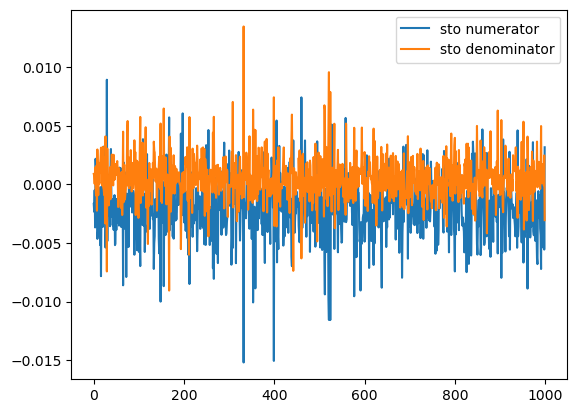

In [116]:
from matplotlib import pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns
plt.plot(numcr_sp.real,label='sto numerator')
plt.plot(dencr_sp.real,label='sto denominator')
plt.legend()
plt.show()

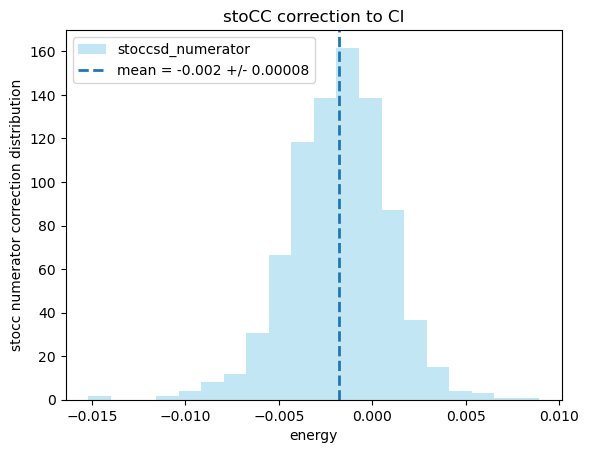

In [117]:
from matplotlib import pyplot as plt
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(numcr_sp.real, bins=20, alpha=0.5, density=True, color='skyblue', label='stoccsd_numerator')
mean = np.mean(numcr_sp.real)
sigma = np.std(numcr_sp.real)/np.sqrt(len(numcr_sp))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
# plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("stocc numerator correction distribution")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

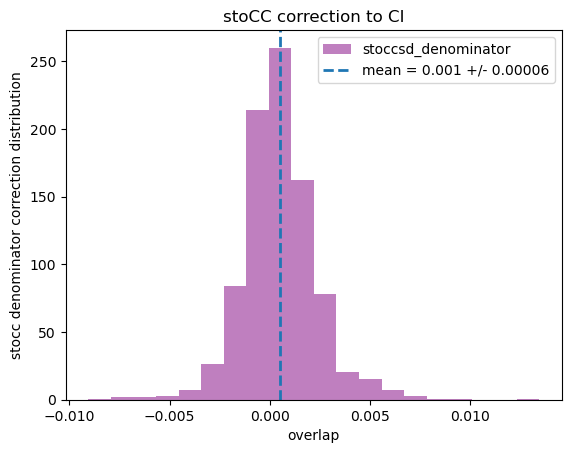

In [118]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(dencr_sp.real, bins=20, alpha=0.5, density=True, color='purple', label='stoccsd_denominator')
mean = np.mean(dencr_sp.real)
sigma = np.std(dencr_sp.real)/np.sqrt(len(dencr_sp))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.3f} +/- {sigma:.5f}")
# plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("overlap")
plt.ylabel("stocc denominator correction distribution")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

In [119]:
whf_jk = whf - whf_sp[:n+1]
numci_jk = (whf_numci - whf_sp[:n+1] * numci_sp[:n+1]) / whf_jk
denci_jk = (whf_denci - whf_sp[:n+1] * denci_sp[:n+1]) / whf_jk
numcr_jk = (whf_numcr - whf_sp[:n+1] * numcr_sp[:n+1]) / whf_jk
dencr_jk = (whf_dencr - whf_sp[:n+1] * dencr_sp[:n+1]) / whf_jk

#CCSD
ecc_jk = (numci_jk + numcr_jk) / (denci_jk + dencr_jk)
# for i in range(len(whf_jk)):
#     print(f'  {i+1}  {ecc_jk.real[i]:.6f}')
ecc_jk_mean = np.sum(ecc_jk) / (n+1)
ecc_jk_err = np.sqrt(np.sum((ecc_jk-ecc_jk_mean)**2) * n/(n+1))
print(f'{ecc_jk_mean.real:.6f} +/- {ecc_jk_err.real:.6f}')

-2.192147 +/- 0.000078


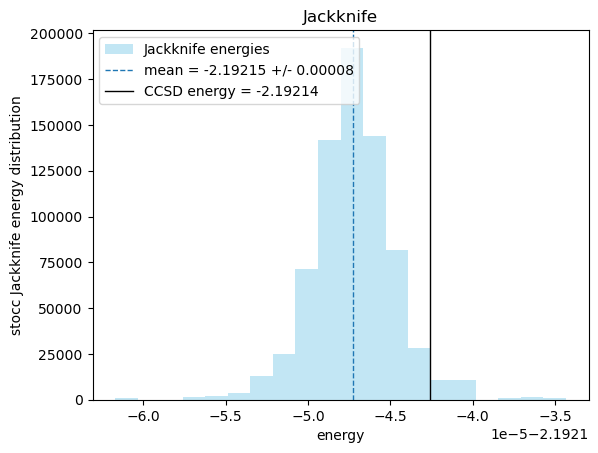

In [121]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(ecc_jk.real, bins=20, alpha=0.5, density=True, color='skyblue', label='Jackknife energies')
mean = np.mean(ecc_jk.real)
sigma = np.std(ecc_jk.real) * np.sqrt(len(ecc_jk))
plt.axvline(mean, linestyle="--", linewidth=1, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=1, color='black', label=f"CCSD energy = {mycc.e_tot:.5f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("stocc Jackknife energy distribution")
plt.title("Jackknife")
plt.legend()
plt.show()

In [69]:
dev = np.abs(ecc_jk.real - ecc_jk.real.mean())

In [ ]:
std = np.std(ecc_jk.real)
z = dev / std
outlier_idx = np.where(z > 10)[0]

In [79]:
outlier_idx

array([673, 852])

In [83]:
median = np.median(ecc_jk.real)
print(median)
mad = np.median(np.abs(ecc_jk.real - median))
print(mad)
z = 0.6745 * (ecc_jk.real - median) / mad
outlier_idx = np.where(np.abs(z) > 20)[0]
print(outlier_idx)

-8.76783682725865
2.3838814004584208e-05
[673 852]


In [87]:
def find_outliers_mad(x, threshold=20.0):
    x = np.asarray(x)

    median = np.median(x)
    mad = np.median(np.abs(x - median))

    # Avoid division-by-zero if all values identical
    if mad == 0:
        return x, np.array([], dtype=int)

    modified_z = 0.6745 * (x - median) / mad
    mask_clean = np.abs(modified_z) <= threshold

    # cleaned = x[mask]
    removed_idx = np.where(~mask_clean)[0]

    return mask_clean, removed_idx

def reomve_outliers(data, mask_clean):
    return [x[mask_clean] for x in data]

In [88]:
mask_clean, outlier_idx = find_outliers_mad(ecc_jk.real, threshold=20.0)
print(outlier_idx)
print(mask_clean.sum())

[673 852]
998


In [90]:
data = [whf_sp, numci_sp, denci_sp, numcr_sp, dencr_sp]
[whf_clean, numci_clean, denci_clean, numcr_clean, dencr_clean] = reomve_outliers(data, mask_clean)

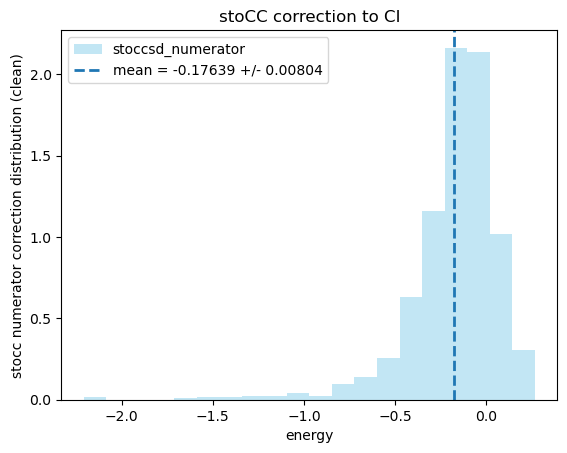

In [95]:
plt.figure()
# plt.hist(energy1.real, bins=10, alpha=0.6, color='skyblue', label='full-stoccsd')
plt.hist(numcr_clean.real, bins=20, alpha=0.5, density=True, color='skyblue', label='stoccsd_numerator')
mean = np.mean(numcr_clean.real)
sigma = np.std(numcr_clean.real)/np.sqrt(len(numcr_clean))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
# plt.axvline(mycc.e_tot, linestyle="-", linewidth=2, color='black', label=f"CCSD energy = {mycc.e_tot:.3f}")
# plt.hist(energy2.real, bins=10, alpha=0.5, density=True, color='purple', label='cisd-stoccsd')
plt.xlabel("energy")
plt.ylabel("stocc numerator correction distribution (clean)")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

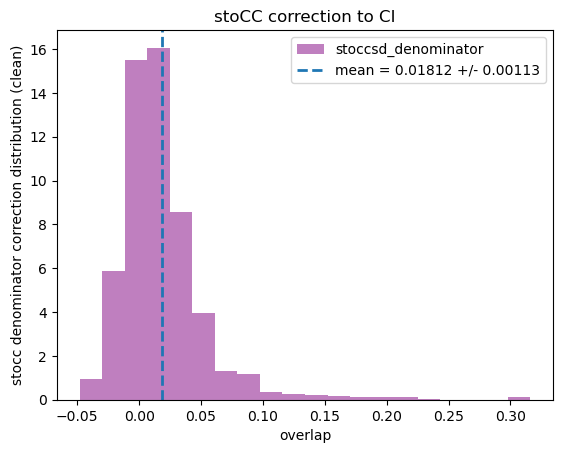

In [94]:
plt.figure()
plt.hist(dencr_clean.real, bins=20, alpha=0.5, density=True, color='purple', label='stoccsd_denominator')
mean = np.mean(dencr_clean.real)
sigma = np.std(dencr_clean.real)/np.sqrt(len(dencr_clean))
plt.axvline(mean, linestyle="--", linewidth=2, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.xlabel("overlap")
plt.ylabel("stocc denominator correction distribution (clean)")
plt.title("stoCC correction to CI")
plt.legend()
plt.show()

In [96]:
whf = np.sum(whf_clean)
whf_numci = np.sum(whf_clean * numci_clean)
whf_denci = np.sum(whf_clean * denci_clean)
whf_numcr = np.sum(whf_clean * numcr_clean)
whf_dencr = np.sum(whf_clean * dencr_clean)

In [99]:
(whf_numci + whf_numcr) / (whf_denci + whf_dencr)

np.complex128(-8.76952657069782+0.00014324040333053414j)

In [100]:
whf_jk = whf - whf_clean
numci_jk = (whf_numci - whf_clean * numci_clean) / whf_jk
denci_jk = (whf_denci - whf_clean * denci_clean) / whf_jk
numcr_jk = (whf_numcr - whf_clean * numcr_clean) / whf_jk
dencr_jk = (whf_dencr - whf_clean * dencr_clean) / whf_jk

#CCSD
ecc_jk = (numci_jk + numcr_jk) / (denci_jk + dencr_jk)
# for i in range(len(whf_jk)):
#     print(f'  {i+1}  {ecc_jk.real[i]:.6f}')
ecc_jk_mean = ecc_jk.mean()
ecc_jk_err = np.std(ecc_jk) * np.sqrt(len(ecc_jk))
print(f'{ecc_jk_mean.real:.6f} +/- {ecc_jk_err.real:.6f}')

-8.769527 +/- 0.001809


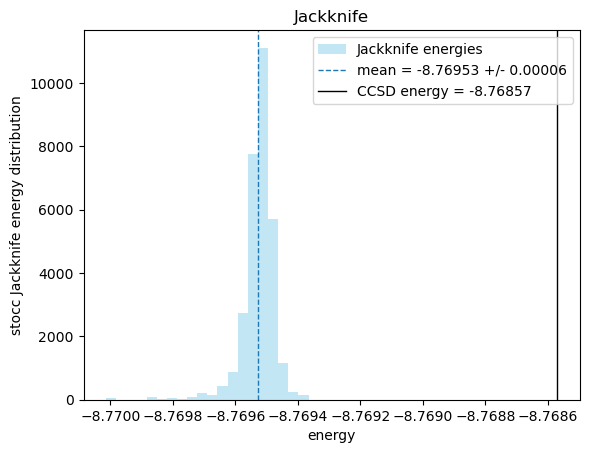

In [101]:
plt.figure()
plt.hist(ecc_jk.real, bins=20, alpha=0.5, density=True, color='skyblue', label='Jackknife energies')
mean = np.mean(ecc_jk.real)
sigma = np.std(ecc_jk.real)
plt.axvline(mean, linestyle="--", linewidth=1, label=f"mean = {mean:.5f} +/- {sigma:.5f}")
plt.axvline(mycc.e_tot, linestyle="-", linewidth=1, color='black', label=f"CCSD energy = {mycc.e_tot:.5f}")
plt.xlabel("energy")
plt.ylabel("stocc Jackknife energy distribution")
plt.title("Jackknife")
plt.legend()
plt.show()